### Stock price prediction project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:

df=pd.read_csv("UPCL.csv")

In [3]:
df

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1
...,...,...,...,...,...,...,...,...,...
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1


In [4]:
df.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1


In [5]:
df.tail()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1
1522,2026-02-17,384.9,384.9,371.4,373.0,-1.17,180630.0,67463595.4,-1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   published_date   1523 non-null   object 
 1   open             1523 non-null   float64
 2   high             1523 non-null   float64
 3   low              1523 non-null   float64
 4   close            1523 non-null   float64
 5   per_change       1523 non-null   float64
 6   traded_quantity  1523 non-null   float64
 7   traded_amount    1523 non-null   float64
 8   status           1523 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 107.2+ KB


In [7]:
#Convert the date in date format
df['published_date'] = pd.to_datetime(df['published_date'])

#sort by date
df = df.sort_values('published_date')

In [8]:
df

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1
...,...,...,...,...,...,...,...,...,...
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1


In [9]:
# ===== Feature Engineering =====



# Moving averages (VERY POWERFUL)
df['ma_5'] = df['close'].rolling(window=5).mean()
df['ma_10'] = df['close'].rolling(window=10).mean()

# Volume moving average
df['vol_ma_5'] = df['traded_quantity'].rolling(window=5).mean()

# Lag feature (EXTREMELY IMPORTANT)
df['close_lag1'] = df['close'].shift(1)

# Momentum
df['momentum_3'] = df['close'] - df['close'].shift(3)

# Volatility
df['volatility_5'] = df['close'].rolling(5).std()

# Price change
df['price_change'] = df['close'] - df['open']

In [10]:
#select the features
features = [
    'open',
    'high',
    'low',
    'close',
    'traded_quantity',
    'ma_5',
    'ma_10',
    'vol_ma_5',
    'close_lag1',
    'momentum_3',
    'volatility_5',
    'price_change'
]


In [11]:
#Create target for next day closing
#This is the most important and core of prediction
df_model = df[features].copy()

# Create target
df_model['Target'] = df['close'].shift(-1)

# Drop NaNs (IMPORTANT — many will appear)
df_model.dropna(inplace=True)

In [12]:
df_model.head()

,open,high,low,close,traded_quantity,ma_5,ma_10,vol_ma_5,close_lag1,momentum_3,volatility_5,price_change,Target
9,100.0,101.0,96.0,97.0,17130.0,97.0,96.6,18893.2,100.0,1.0,1.870829,-3.0,95.0
10,98.0,98.0,93.0,95.0,4686.0,96.6,96.6,14263.4,97.0,0.0,2.073644,-3.0,98.0
11,94.0,98.0,93.0,98.0,3015.0,97.0,96.4,13920.4,95.0,-2.0,2.121320,4.0,92.0
12,97.0,97.0,92.0,92.0,16384.0,96.4,96.0,15964.0,98.0,-5.0,3.049590,-5.0,92.0
13,93.0,95.0,91.0,92.0,17080.0,94.8,95.6,11659.0,92.0,-3.0,2.774887,-1.0,92.0


In [13]:
df.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,ma_5,ma_10,vol_ma_5,close_lag1,momentum_3,volatility_5,price_change
0,2019-05-21,91.0,97.0,91.0,95.0,3.26,14515.0,1368205.0,1,NaN,NaN,NaN,NaN,NaN,NaN,4.0
1,2019-05-22,96.0,102.0,96.0,100.0,5.26,51310.0,5040190.0,1,NaN,NaN,NaN,95.0,NaN,NaN,4.0
2,2019-05-23,98.0,102.0,94.0,96.0,-4.00,20010.0,1941570.0,-1,NaN,NaN,NaN,100.0,NaN,NaN,-2.0
3,2019-05-26,96.0,96.0,94.0,96.0,0.00,6955.0,659760.0,0,NaN,NaN,NaN,96.0,1.0,NaN,0.0
4,2019-05-27,96.0,96.0,94.0,94.0,-2.08,3692.0,350186.0,-1,96.2,NaN,19296.4,96.0,-6.0,2.280351,-2.0


In [14]:
df_model.tail()

,open,high,low,close,traded_quantity,ma_5,ma_10,vol_ma_5,close_lag1,momentum_3,volatility_5,price_change,Target
1517,381.0,381.0,371.0,372.0,150551.0,376.60,380.99,167765.8,377.0,-4.0,5.128353,-9.0,375.0
1518,364.6,381.0,364.6,375.0,207322.0,377.00,379.50,179007.4,372.0,-10.0,4.847680,10.4,379.5
1519,375.0,384.4,375.0,379.5,183138.0,377.70,377.95,190405.4,375.0,2.5,4.919350,4.5,382.1
1520,372.0,392.7,372.0,382.1,365311.0,377.12,377.06,213553.8,379.5,10.1,3.911138,10.1,377.4
1521,375.0,387.8,375.0,377.4,135659.0,377.20,376.90,208396.2,382.1,2.4,3.912161,2.4,373.0


In [15]:
df.tail()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,ma_5,ma_10,vol_ma_5,close_lag1,momentum_3,volatility_5,price_change
1518,2026-02-10,364.6,381.0,364.6,375.0,0.81,207322.0,78142545.9,1,377.00,379.50,179007.4,372.0,-10.0,4.847680,10.4
1519,2026-02-11,375.0,384.4,375.0,379.5,1.20,183138.0,69589109.8,1,377.70,377.95,190405.4,375.0,2.5,4.919350,4.5
1520,2026-02-12,372.0,392.7,372.0,382.1,0.69,365311.0,141396818.9,1,377.12,377.06,213553.8,379.5,10.1,3.911138,10.1
1521,2026-02-16,375.0,387.8,375.0,377.4,-1.23,135659.0,51723961.8,1,377.20,376.90,208396.2,382.1,2.4,3.912161,2.4
1522,2026-02-17,384.9,384.9,371.4,373.0,-1.17,180630.0,67463595.4,-1,377.40,377.00,214412.0,377.4,-6.5,3.592353,-11.9


In [16]:
df.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1513, 1514, 1515, 1516, 1517, 1518, 1519, 1520, 1521, 1522],
      dtype='int64', length=1523)

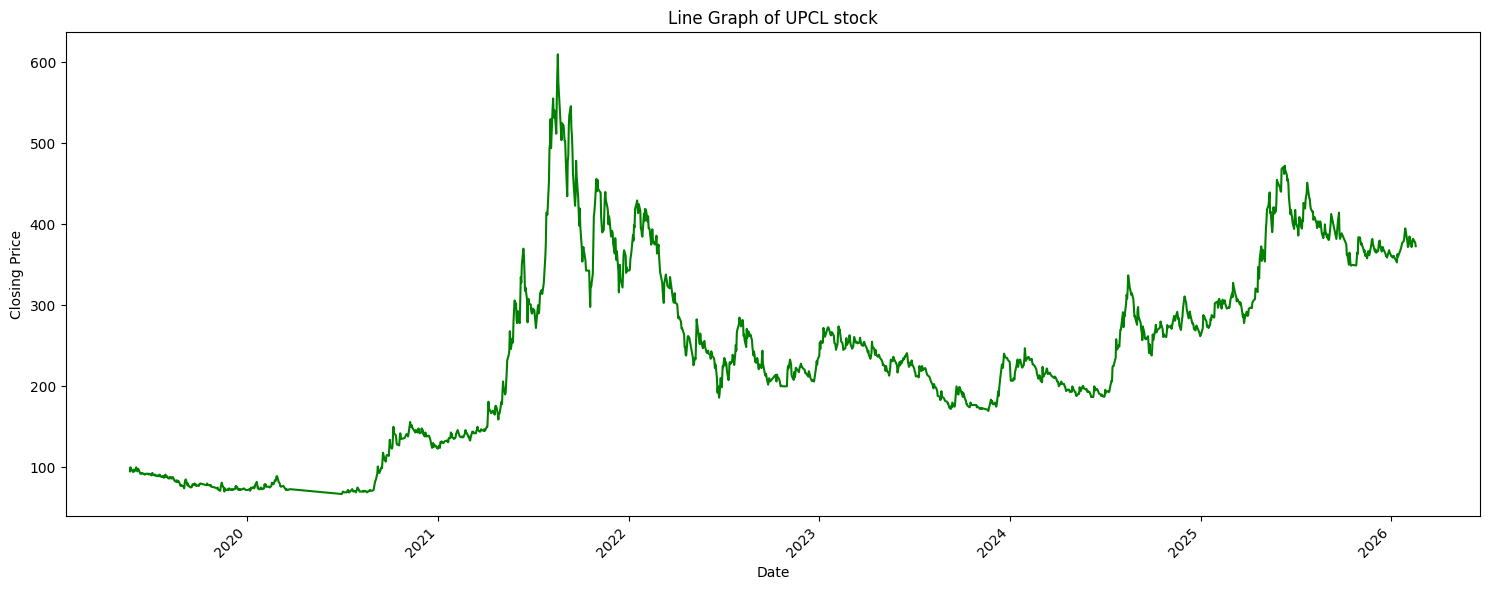

In [17]:
plt.figure(figsize=(15,6))
plt.plot(df['published_date'],df['close'],color="Green")
plt.xlabel("Date")
plt.title("Line Graph of UPCL stock")
plt.ylabel("Closing Price")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

In [18]:
df_model.corr()

,open,high,low,close,traded_quantity,ma_5,ma_10,vol_ma_5,close_lag1,momentum_3,volatility_5,price_change,Target
open,1.000000,0.998449,0.998594,0.996601,0.515714,0.997007,0.991569,0.572481,0.999423,0.034128,0.647725,-0.129744,0.992653
high,0.998449,1.000000,0.998157,0.998656,0.530970,0.996620,0.990647,0.580257,0.998374,0.054131,0.666378,-0.086206,0.995059
low,0.998594,0.998157,1.000000,0.998231,0.514628,0.997005,0.991686,0.569388,0.998644,0.046578,0.634346,-0.093090,0.994263
close,0.996601,0.998656,0.998231,1.000000,0.530035,0.995826,0.989734,0.576043,0.996654,0.071297,0.654232,-0.047624,0.996653
traded_quantity,0.515714,0.530970,0.514628,0.530035,1.000000,0.500189,0.470489,0.917296,0.512757,0.324176,0.489171,0.126571,0.532481
ma_5,0.997007,0.996620,0.997005,0.995826,0.500189,1.000000,0.996933,0.560733,0.997952,-0.015265,0.639355,-0.102786,0.992299
ma_10,0.991569,0.990647,0.991686,0.989734,0.470489,0.996933,1.000000,0.530375,0.992707,-0.046857,0.624836,-0.110175,0.986027
vol_ma_5,0.572481,0.580257,0.569388,0.576043,0.917296,0.560733,0.530375,1.000000,0.570478,0.177622,0.488819,-0.007975,0.578003
close_lag1,0.999423,0.998374,0.998644,0.996654,0.512757,0.997952,0.992707,0.570478,1.000000,0.025494,0.646736,-0.122123,0.992928
momentum_3,0.034128,0.054131,0.046578,0.071297,0.324176,-0.015265,-0.046857,0.177622,0.025494,1.000000,0.177535,0.444373,0.073408


In [36]:
#manual split of data for taining and testing
X = df_model[features]
y = df_model['Target']

X_train = X.iloc[:-200]
X_test  = X.iloc[-200:]

y_train = y.iloc[:-200]
y_test  = y.iloc[-200:]

In [37]:
#train using random forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    min_samples_split=8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=3, min_samples_split=8,
                      n_estimators=500, n_jobs=-1, random_state=42)

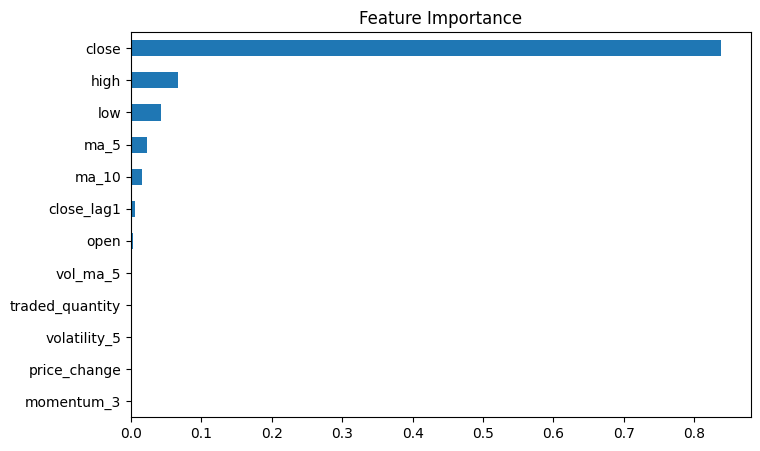

In [38]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

In [39]:
#Predict and evaluate
preds = model.predict(X_test)

from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error
print("R2 score:", r2_score(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("MAE:", mean_absolute_error(y_test, preds))

R2 score: 0.8990708492853419
RMSE: 11.830481415968238
MAE: 9.105984704447655


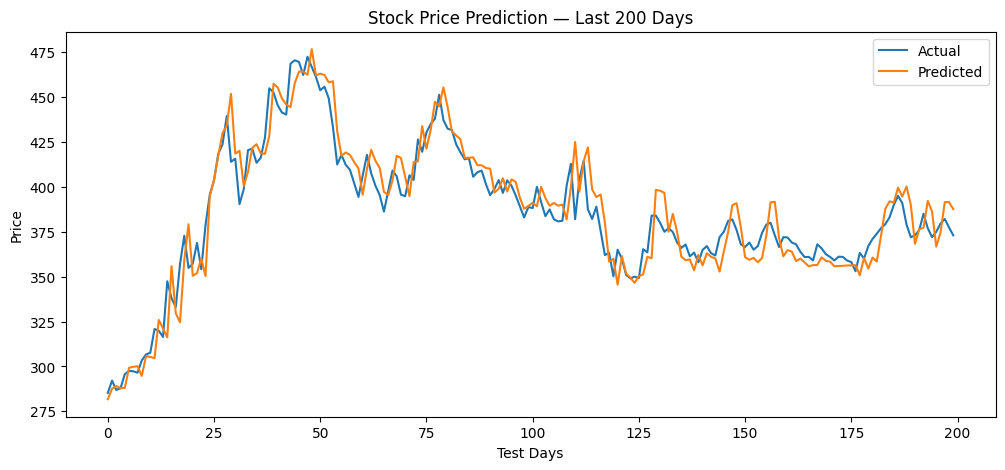

In [48]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("Stock Price Prediction — Last 200 Days")
plt.xlabel("Test Days")
plt.ylabel("Price")
plt.legend()
plt.savefig("assets/results.png", bbox_inches="tight")
plt.show()

In [46]:
mkdir model


In [47]:
import joblib
joblib.dump(model, "model/stock_model.pkl")

['model/stock_model.pkl']

In [2]:
import sklearn
print(sklearn.__version__)

1.2.0
